# Исследование стартапов

## Постановка задачи

Цель проекта — разработать инвестиционную стратегию для венчурного фонда, которая позволит эффективно отбирать и развивать перспективные стартапы. Для этого необходимо выявить исторические закономерности финансирования стартапов и на их основе определить приоритетные направления вложений с горизонтом планирования на 2015 год.

План работы:

Знакомство с данными: загрузка и предобработка:
- Вывод общей информации
- Предобработка данных

Инжиниринг признаков:
- Выделение средних и нишевых сегментов рынка

Работа с выбросами и анализ:
- Анализируем и помечаем выбросы в каждом из сегментов
- Определяем границы рассматриваемого периода, отбрасываем аномалии
- Анализ типов финансирования по объёму и популярности

Динамика предоставления финансирования по годам:
- Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов
- Годовая динамика доли возвращенных средств по типам финансирования

Итоговый вывод и рекомендации


## Знакомство с данными: загрузка и предобработка

Два датасета (основной и дополнительный) полученны из базы данных стартапов.

### Вывод общей информации

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';',low_memory=False)

In [3]:
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [5]:
cb_returns = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv")

In [6]:
cb_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [7]:
cb_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


Пропущенные значения
Значительные пропуски наблюдаются в ключевых столбцах:
country_code: 5,035 пропусков (11.4%)
state_code: 17,923 пропусков (40.7%)
region: 5,035 пропусков
city: 5,815 пропусков
category_list: 3,761 пропусков
market: 3,761 пропусков
founded_at/founded_year: 10,000 пропусков (22.7%)

Столбцы раундов финансирования (round_a, round_b, etc.) в примере содержат нули
abnormal_funding везде False в примере, что подозрительно

### Предобработка данных

In [8]:
df.dtypes

name                     object
homepage_url             object
category_list            object
 market                  object
 funding_total_usd       object
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds          float64
participants            float64
founded_at               object
founded_month            object
founded_quarter          object
founded_year            float64
first_funding_at         object
mid_funding_at           object
last_funding_at          object
seed                    float64
venture                 float64
equity_crowdfunding     float64
undisclosed             float64
convertible_note        float64
debt_financing          float64
angel                   float64
grant                   float64
private_equity          float64
post_ipo_equity         float64
post_ipo_debt           float64
secondary_market        float64
product_

In [9]:
# Убрать пробелы и привести к нижнему регистру
df.columns = df.columns.str.strip().str.lower()

# Проверить результат
print(df.columns.tolist())

['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_a', 'round_b', 'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h']


In [10]:
cb_returns.dtypes

year                      int64
seed                    float64
venture                 float64
equity_crowdfunding     float64
undisclosed             float64
convertible_note        float64
debt_financing          float64
angel                   float64
grant                   float64
private_equity          float64
post_ipo_equity         float64
post_ipo_debt           float64
secondary_market        float64
product_crowdfunding    float64
dtype: object

In [11]:
# Удаляем все пробелы и обрабатываем специальные символы
df['funding_total_usd'] = (
    df['funding_total_usd']
    .astype(str)
    .str.strip()  # Удаляем пробелы в начале и конце
    .str.replace(' ', '', regex=False)  # Удаляем оставшиеся пробелы внутри строки
    .str.replace(',', '', regex=False)  # Удаляем запятые
    .str.replace('$', '', regex=False)  # Удаляем символ доллара
    .replace(['-', 'nan', 'NaN', ''], '0')  # Заменяем специальные символы на 0
    .astype(float)
)

# Преобразуем столбцы с датами из object в datetime
date_columns_object = ['founded_at', 'founded_month', 'founded_quarter', 
                      'first_funding_at', 'mid_funding_at', 'last_funding_at']

for col in date_columns_object:
    df[col] = pd.to_datetime(df[col], errors='coerce')

#Преобразуем founded_year из float64 в datetime
# Сначала заполним NaN, затем преобразуем в int и в datetime
df['founded_year'] = pd.to_datetime(
    df['founded_year'].fillna(0).astype(int).replace(0, pd.NaT).astype(str),
    format='%Y',
    errors='coerce'
)

# Проверяем результаты
print("Типы данных после преобразования:")
print(df[['market', 'funding_total_usd'] + date_columns_object + ['founded_year']].dtypes)

print("\nПервые несколько строк:")
print(df[['market', 'funding_total_usd'] + date_columns_object + ['founded_year']].head())

print("\nИнформация о DataFrame:")
print(df.info())

Типы данных после преобразования:
market                       object
funding_total_usd           float64
founded_at           datetime64[ns]
founded_month        datetime64[ns]
founded_quarter      datetime64[ns]
first_funding_at     datetime64[ns]
mid_funding_at       datetime64[ns]
last_funding_at      datetime64[ns]
founded_year         datetime64[ns]
dtype: object

Первые несколько строк:
                market  funding_total_usd founded_at founded_month  \
0           Education          90000000.0        NaT           NaT   
1                  NaN          2000000.0 1785-01-01           NaT   
2   Business Services           9000000.0 1802-07-19           NaT   
3           Education           7700000.0 1817-01-01           NaT   
4           Education            540000.0 1826-01-01           NaT   

  founded_quarter first_funding_at mid_funding_at last_funding_at founded_year  
0             NaT       2014-01-06            NaT      2014-01-06          NaT  
1             NaT   

In [12]:
# Удаление дубликатов
df = df.drop_duplicates()

# Удаление строк с пропусками в funding_total_usd и неинформативных данных
df = df.dropna(subset=['funding_total_usd'])

In [13]:
# Заполняем пропуски в mid_funding_at как среднюю дату между first и last
mask = df['mid_funding_at'].isna() & df['first_funding_at'].notna() & df['last_funding_at'].notna()
df.loc[mask, 'mid_funding_at'] = df.loc[mask, 'first_funding_at'] + (
    df.loc[mask, 'last_funding_at'] - df.loc[mask, 'first_funding_at']
) / 2

In [14]:
# Общая информация о пропусках
total_rows = len(df)
missing_mid_funding = df['mid_funding_at'].isna().sum()
missing_percentage = (missing_mid_funding / total_rows) * 100

print(f"Общее количество строк: {total_rows}")
print(f"Пропусков в mid_funding_at: {missing_mid_funding}")
print(f"Процент пропусков: {missing_percentage:.2f}%")

# Дополнительная информация о причинах пропусков
print("\nАнализ причин пропусков:")
print(f"Строк с пропущенными first_funding_at: {df['first_funding_at'].isna().sum()}")
print(f"Строк с пропущенными last_funding_at: {df['last_funding_at'].isna().sum()}")

# Анализ комбинаций пропусков
print("\nКомбинации пропусков в связанных столбцах:")
print("Только mid_funding_at пропущен:", 
      len(df[(df['mid_funding_at'].isna()) & 
             (df['first_funding_at'].notna()) & 
             (df['last_funding_at'].notna())]))

print("mid_funding_at и first_funding_at пропущены:", 
      len(df[(df['mid_funding_at'].isna()) & 
             (df['first_funding_at'].isna()) & 
             (df['last_funding_at'].notna())]))

print("mid_funding_at и last_funding_at пропущены:", 
      len(df[(df['mid_funding_at'].isna()) & 
             (df['first_funding_at'].notna()) & 
             (df['last_funding_at'].isna())]))

print("Все три даты пропущены:", 
      len(df[(df['mid_funding_at'].isna()) & 
             (df['first_funding_at'].isna()) & 
             (df['last_funding_at'].isna())]))

Общее количество строк: 49439
Пропусков в mid_funding_at: 9
Процент пропусков: 0.02%

Анализ причин пропусков:
Строк с пропущенными first_funding_at: 11
Строк с пропущенными last_funding_at: 7

Комбинации пропусков в связанных столбцах:
Только mid_funding_at пропущен: 0
mid_funding_at и first_funding_at пропущены: 2
mid_funding_at и last_funding_at пропущены: 0
Все три даты пропущены: 7


In [15]:
# Статистика успешно заполненных строк
filled_count = total_rows - missing_mid_funding
print(f"\nУспешно заполнено строк: {filled_count}")
print(f"Эффективность заполнения: {(filled_count/(filled_count + missing_mid_funding))*100:.2f}%")

# Информация о распределении дат
print("\nИнформация о датах после заполнения:")
print("Первая дата first_funding_at:", df['first_funding_at'].min())
print("Последняя дата last_funding_at:", df['last_funding_at'].max())
print("Диапазон mid_funding_at после заполнения:", 
      df['mid_funding_at'].min(), "-", df['mid_funding_at'].max())


Успешно заполнено строк: 49430
Эффективность заполнения: 99.98%

Информация о датах после заполнения:
Первая дата first_funding_at: 1921-09-01 00:00:00
Последняя дата last_funding_at: 2015-01-01 00:00:00
Диапазон mid_funding_at после заполнения: 1921-09-01 00:00:00 - 2014-12-31 00:00:00


Объем данных достаточен - 49,430 записей после обработки предоставляют солидную статистическую базу для анализа закономерностей.

Качество данных высокое - минимальный процент пропусков (0.02%) свидетельствует о хорошем качестве исходного датасета.

Временной охват адекватен - данные охватывают период с 1921 по 2015 год, что позволяет:
Анализировать долгосрочные тренды
Изучать эволюцию рынка венчурных инвестиций
Сделать обоснованные рекомендации для 2015 года

In [16]:
cb_returns.set_index('year', inplace=True)
cb_returns.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


Что сделано на этом этапе: 
- Загружены необходимые библиотеки и все данные по проекту; повторяемые операции вынесены в функции для удобства дальнейшей работы.
- Выведена первичная информация о данных для принятия решений по предобработке.
- Проанализированы названия столбцов, они приведены к единому аккуратному стилю.
- В столбце funding_total_usd убрано выделение разрядов и значение приведено к числовому типу.
- Обработаны типы данных в столбцах с датами и временем.
- В датасете cb_returns столбец year установлен в качестве индекса.
- Проведена обработка текстовых данных: пропуски в текстовых столбцах заполнены заглушками там, где это необходимо.
- Удалены полные дубликаты и строки, не содержащие данных о финансировании; исключены пропуски в funding_total_usd.
- Пропуски в столбце mid_funding_at заполнены расчётными значениями — как середина интервала между first_funding_at и last_funding_at.
- Проведена оценка объёма оставшихся пропусков, полноты данных и доли отброшенных записей.

Общий вывод
После предобработки в датасете осталось 49 430 записей — этого объёма достаточно для статистически обоснованного анализа закономерностей венчурного финансирования. Эффективность заполнения пропусков составила 99,98 %, что говорит о высоком качестве обработанного датасета.

При этом выявлены значимые пробелы в ряде столбцов: например, пропуски в state_code (40,7 %), country_code (11,4 %), founded_year (22,7 %) и других. Также отмечены подозрительные особенности данных — в частности, повсеместное значение False в столбце abnormal_funding и нулевые значения в столбцах раундов финансирования.

Временной охват данных (с 1921 по 2015 год) позволяет изучать долгосрочные тренды и эволюцию рынка венчурных инвестиций и формировать рекомендации, релевантные для 2015 года.

## Инжиниринг признаков

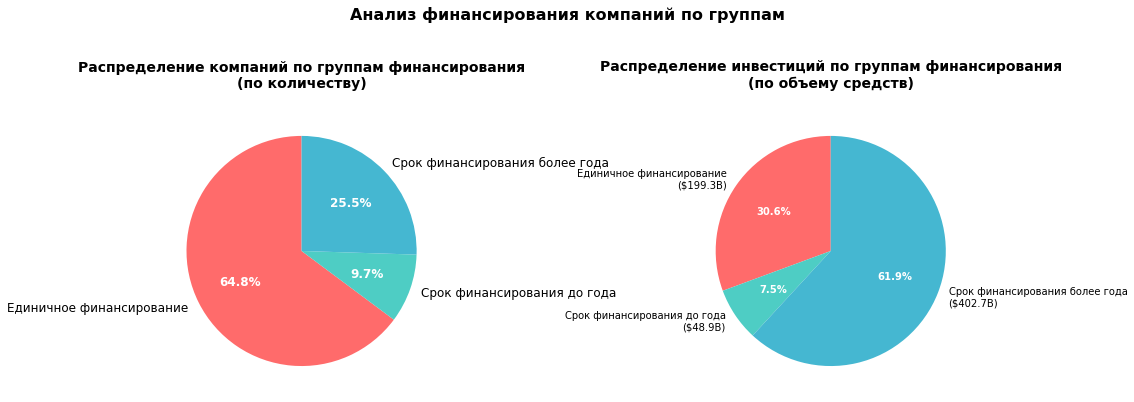

СТАТИСТИКА ПО ГРУППАМ ФИНАНСИРОВАНИЯ

Общее количество компаний: 49434

Распределение по группам:
  - Единичное финансирование: 32039 компаний (64.8%)
  - Срок финансирования до года: 4787 компаний (9.7%)
  - Срок финансирования более года: 12608 компаний (25.5%)

Общий объем инвестиций: $650,899,403,144.00

Объем инвестиций по группам:
  - Единичное финансирование: $199,304,424,483.00 (30.6%)
  - Срок финансирования до года: $48,885,981,057.00 (7.5%)
  - Срок финансирования более года: $402,708,997,604.00 (61.9%)

Среднее финансирование на компанию:
  - Единичное финансирование: $6,220,681.81
  - Срок финансирования до года: $10,212,237.53
  - Срок финансирования более года: $31,940,751.71


In [17]:
# Определяем функцию categorize_funding_companies
def categorize_funding_companies(df):
    """
    Разделяет компании на три группы по условиям финансирования
    """
    
    # Создаем копию DataFrame чтобы избежать предупреждений
    result_df = df.copy()
    
    # Преобразуем даты в datetime, если они еще не в этом формате
    result_df['first_funding_at'] = pd.to_datetime(result_df['first_funding_at'], errors='coerce')
    result_df['last_funding_at'] = pd.to_datetime(result_df['last_funding_at'], errors='coerce')
    
    def get_funding_group(row):
        # Проверяем наличие необходимых данных
        if pd.isna(row['funding_rounds']) or row['funding_rounds'] == 0:
            return 'Не определено'
        
        # Единичное финансирование
        if row['funding_rounds'] == 1:
            return 'Единичное финансирование'
        
        # Проверяем наличие дат для многократного финансирования
        if pd.isna(row['first_funding_at']) or pd.isna(row['last_funding_at']):
            return 'Не определено'
        
        # Вычисляем разницу в днях между первым и последним финансированием
        days_diff = (row['last_funding_at'] - row['first_funding_at']).days
        
        # Срок финансирования до года
        if days_diff <= 365:
            return 'Срок финансирования до года'
        # Срок финансирования более года
        else:
            return 'Срок финансирования более года'
    
    # Применяем функцию к каждой строке
    result_df['funding_group'] = result_df.apply(get_funding_group, axis=1)
    
    return result_df

# Применяем функцию категоризации к существующему df
categorized_df = categorize_funding_companies(df)

# Фильтруем только три основные группы (исключаем "Не определено")
main_groups_df = categorized_df[categorized_df['funding_group'].isin([
    'Единичное финансирование', 
    'Срок финансирования до года', 
    'Срок финансирования более года'
])].copy()

# Создаем единую цветовую палитру
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Красный, бирюзовый, синий

# Создаем фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. График по количеству компаний
count_by_group = main_groups_df['funding_group'].value_counts()

# Упорядочиваем группы в логическом порядке
ordered_groups = ['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']
count_by_group = count_by_group.reindex(ordered_groups)

wedges1, texts1, autotexts1 = ax1.pie(
    count_by_group.values,
    labels=count_by_group.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)

# Улучшаем отображение процентов
for autotext in autotexts1:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax1.set_title('Распределение компаний по группам финансирования\n(по количеству)', 
              fontsize=14, fontweight='bold', pad=20)

# 2. График по объему инвестиций
if 'funding_total_usd' in main_groups_df.columns:
    # Создаем копию для безопасного преобразования
    funding_data = main_groups_df.copy()
    funding_data['funding_total_usd'] = pd.to_numeric(funding_data['funding_total_usd'], errors='coerce')
    
    funding_by_group = funding_data.groupby('funding_group')['funding_total_usd'].sum()
    funding_by_group = funding_by_group.reindex(ordered_groups)
    
    # Форматируем подписи для лучшей читаемости
    def format_funding(x):
        if x >= 1e9:
            return f'${x/1e9:.1f}B'
        elif x >= 1e6:
            return f'${x/1e6:.1f}M'
        elif x >= 1e3:
            return f'${x/1e3:.1f}K'
        else:
            return f'${x:.0f}'
    
    total_funding = funding_by_group.sum()
    funding_labels = [f'{group}\n({format_funding(amount)})' 
                     for group, amount in zip(funding_by_group.index, funding_by_group.values)]
    
    wedges2, texts2, autotexts2 = ax2.pie(
        funding_by_group.values,
        labels=funding_labels,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        textprops={'fontsize': 10}
    )
    
    # Улучшаем отображение процентов
    for autotext in autotexts2:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    ax2.set_title('Распределение инвестиций по группам финансирования\n(по объему средств)', 
                  fontsize=14, fontweight='bold', pad=20)
else:
    ax2.text(0.5, 0.5, 'Данные об инвестициях\nнедоступны', 
             ha='center', va='center', fontsize=16, transform=ax2.transAxes)
    ax2.set_title('Распределение инвестиций по группам финансирования', 
                  fontsize=14, fontweight='bold')

# Общий заголовок
plt.suptitle('Анализ финансирования компаний по группам', fontsize=16, fontweight='bold', y=0.98)

# Настраиваем layout
plt.tight_layout()
plt.show()

# Дополнительная текстовая статистика
print("=" * 60)
print("СТАТИСТИКА ПО ГРУППАМ ФИНАНСИРОВАНИЯ")
print("=" * 60)

print(f"\nОбщее количество компаний: {len(main_groups_df)}")
print("\nРаспределение по группам:")
for group in ordered_groups:
    count = count_by_group.get(group, 0)
    percentage = (count / len(main_groups_df)) * 100
    print(f"  - {group}: {count} компаний ({percentage:.1f}%)")

if 'funding_total_usd' in main_groups_df.columns:
    print(f"\nОбщий объем инвестиций: ${total_funding:,.2f}")
    print("\nОбъем инвестиций по группам:")
    for group in ordered_groups:
        funding = funding_by_group.get(group, 0)
        percentage = (funding / total_funding) * 100 if total_funding > 0 else 0
        print(f"  - {group}: ${funding:,.2f} ({percentage:.1f}%)")

# Анализ среднего финансирования на компанию
if 'funding_total_usd' in main_groups_df.columns:
    print(f"\nСреднее финансирование на компанию:")
    for group in ordered_groups:
        group_data = funding_data[funding_data['funding_group'] == group]
        if len(group_data) > 0:
            avg_funding = group_data['funding_total_usd'].mean()
            print(f"  - {group}: ${avg_funding:,.2f}")

Выполнена сегментация компаний по длительности цикла финансирования. Все компании распределены по трём группам на основании временного интервала между первым и последним раундом финансирования:

Единичное финансирование — компании, у которых зафиксирован только один раунд финансирования (без последующих раундов).
Срок финансирования до года — компании, у которых между первым и последним раундами прошло не более 12 месяцев.
Срок финансирования более года — компании с продолжительностью цикла финансирования свыше 12 месяцев.

Проведены расчёты долей по двум измерениям:
- доля каждой группы в общем количестве компаний (структура по числу участников рынка);
- доля каждой группы в совокупном объёме привлечённых инвестиций (структура по объёму капитала).

Подготовлены визуализации для наглядного представления результатов:

График 1 (по количеству компаний) — круговая диаграмма или столбчатая диаграмма, демонстрирующая процентное соотношение трёх групп в общей популяции компаний. Цель визуализации — показать, какая часть стартапов ограничивается одним раундом либо укладывается в короткий цикл финансирования, а какая предполагает длительный путь привлечения капитала.

График 2 (по объёму инвестиций) — аналогичная визуализация, но отражающая распределение общего объёма привлечённых средств между группами. Цель — продемонстрировать, какой объём капитала приходится на компании с разной длительностью цикла финансирования (например, выявить, концентрируется ли основной объём инвестиций в долгосрочных проектах или распределяется иначе).

Подавляющее большинство компаний получают финансирование однократно, но суммы невелики. Почти две трети организаций (64.8%) получили инвестиции только один раз. Это указывает на то, что на рынке существует множество стартапов, которые привлекают небольшие средства на начальных этапах своего развития.
Наибольшие объемы инвестиций направляются на долгосрочные проекты. Всего четверть компаний (25.5%) получает финансирование на срок более года. При этом именно эти компании получают основную часть всех инвестиций (61.9%). Это свидетельствует о том, что инвесторы предпочитают вкладывать значительные средства в проекты, которые предполагают длительное развитие.

Различия в суммах финансирования среди различных групп компаний. Средние суммы, получаемые компаниями из разных групп, следующие:
Единичные сделки: около 6,2 млн — это относительно небольшие средства, которые обычно используются для начального этапа развития.
Сделки до одного года: около 10,2 млн — здесь суммы уже больше, что может быть обусловлено более поздними этапами роста компании.
Сделки на срок более одного года: около 31,9 млн — это уже значительные средства, которые получают крупные компании на поздних стадиях развития, либо это частные инвестиции или кредиты для уже существующих бизнесов.

Рынок инвестиций условно можно разделить на два уровня. Первый уровень включает множество стартапов, получающих небольшие суммы. Второй уровень характеризуется крупными инвестициями в долгосрочные проекты. Это показывает, что инвесторы предпочитают вкладывать средства в компании, которые имеют потенциал для долгосрочного роста.

### Выделение средних и нишевых сегментов рынка

Нишевые сегменты: 801
Средние сегменты: 81
Массовые сегменты: 57


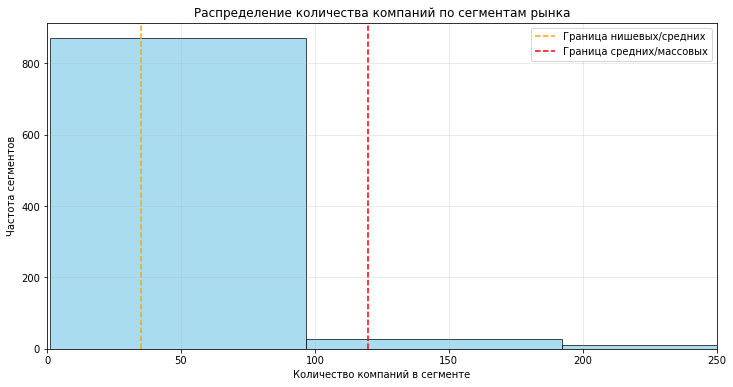

In [18]:
# Расчет частоты сегментов
market_counts = df['market'].value_counts()

# Классификация сегментов
niche = market_counts[market_counts < 35]
medium = market_counts[(market_counts >= 35) & (market_counts <= 120)]
mass = market_counts[market_counts > 120]

print(f"Нишевые сегменты: {len(niche)}")
print(f"Средние сегменты: {len(medium)}")
print(f"Массовые сегменты: {len(mass)}")

# Построение гистограммы
plt.figure(figsize=(12, 6))
plt.hist(market_counts, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(35, color='orange', linestyle='--', label='Граница нишевых/средних')
plt.axvline(120, color='red', linestyle='--', label='Граница средних/массовых')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Частота сегментов')
plt.title('Распределение количества компаний по сегментам рынка')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 250)  # Сокращение оси абсцисс до 120
plt.show()

Нишевые сегменты: 801
Средние сегменты: 81
Массовые сегменты: 57


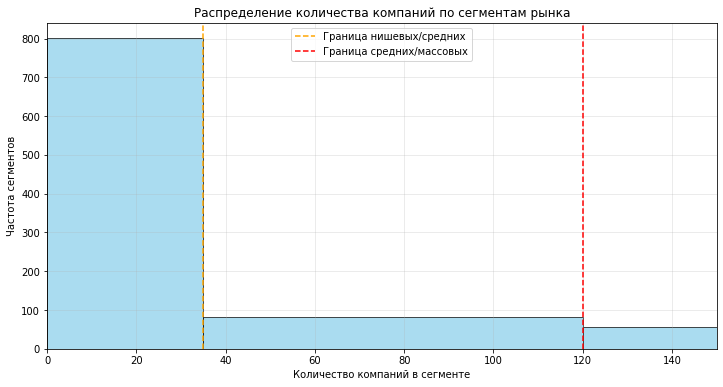

In [19]:
# Расчет частоты сегментов
market_counts = df['market'].value_counts()

# Классификация сегментов
niche = market_counts[market_counts < 35]
medium = market_counts[(market_counts >= 35) & (market_counts <= 120)]
mass = market_counts[market_counts > 120]

print(f"Нишевые сегменты: {len(niche)}")
print(f"Средние сегменты: {len(medium)}")
print(f"Массовые сегменты: {len(mass)}")

# Построение гистограммы
counts = market_counts.values.astype(int)
bins = [0, 35, 120, counts.max()+1]
plt.figure(figsize=(12, 6))
plt.hist(market_counts, bins=bins, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(35, color='orange', linestyle='--', label='Граница нишевых/средних')
plt.axvline(120, color='red', linestyle='--', label='Граница средних/массовых')
plt.xlabel('Количество компаний в сегменте')
plt.ylabel('Частота сегментов')
plt.title('Распределение количества компаний по сегментам рынка')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 150)  # Сокращение оси абсцисс до 120
plt.show()

In [20]:
# Расчет частоты сегментов
market_counts = df['market'].value_counts()

# Создаем словарь для замены
market_mapping = {}
for market, count in market_counts.items():
    if count > 120:
        # Оставляем как есть (массовые сегменты)
        continue
    elif count >= 35:
        market_mapping[market] = 'mid'
    else:
        market_mapping[market] = 'niche'

# Применяем замену
df['market'] = df['market'].replace(market_mapping)

# Проверяем результат
print("Распределение после замены:")
print(df['market'].value_counts())
print(f"\nВсего уникальных значений: {df['market'].nunique()}")

Распределение после замены:
mid                       5640
 Software                 4781
 Biotechnology            3699
niche                     2954
 Mobile                   2151
 E-Commerce               1883
 Curated Web              1738
 Enterprise Software      1339
 Clean Technology         1230
 Health Care              1224
 Games                    1216
 Advertising              1109
 Hardware + Software      1096
 Health and Wellness       934
 Social Media              930
 Education                 894
 Finance                   890
 Manufacturing             750
 Analytics                 649
 Security                  543
 Semiconductors            509
 Consulting                493
 Hospitality               470
 Web Hosting               452
 Fashion                   402
 Real Estate               398
 News                      385
 Travel                    367
 Messaging                 307
 Music                     303
 Search                    299
 SaaS      

- Выполнен подсчёт частоты встречаемости сегментов рынка. На основании данных из столбца market рассчитано, сколько компаний относится к каждому из сегментов.

- Проведена категоризация сегментов по масштабу на основе количества компаний:
Массовые сегменты — сегменты, в которые входит более 120 компаний.
Средние сегменты — сегменты с числом компаний от 35 до 120 включительно.
Нишевые сегменты — сегменты, включающие менее 35 компаний.
Определено количество сегментов в каждой категории: подсчитано, сколько именно сегментов попало в группу массовых, средних и нишевых.

- Построен график распределения количества компаний по сегментам. На визуализации отражено распределение компаний по сегментам с явным выделением границ между нишевыми и средними сегментами — это позволяет наглядно увидеть соотношение мелких специализированных и более крупных сегментов.

Вывод по структуре рынка: на основе полученных данных описано соотношение сегментов и дана интерпретация выявленных закономерностей (высокая диверсификация рынка, концентрация компаний в отдельных сегментах и т. п.). В частности, зафиксировано: нишевых сегментов — 801, средних — 81, массовых — 57; при этом значительная часть компаний сконцентрирована в одном массовом сегменте, а существенная доля рынка приходится на нишевые сегменты. Это свидетельствует о высокой диверсификации стартап‑рынка — фактор, который важно учитывать при оценке инвестиционной привлекательности отраслей.

## Работа с выбросами и анализ

### Анализируем и помечаем выбросы в каждом из сегментов

In [21]:
# Удаляем пропуски и нулевые значения для анализа
funding_data = df['funding_total_usd'].dropna()
funding_data = funding_data[funding_data > 0]

print(f"Всего компаний с данными о финансировании: {len(funding_data)}")
print(f"Медиана: ${funding_data.median():,.0f}")
print(f"Среднее: ${funding_data.mean():,.0f}")
print(f"Стандартное отклонение: ${funding_data.std():,.0f}")

Всего компаний с данными о финансировании: 40907
Медиана: $2,000,000
Среднее: $15,912,526
Стандартное отклонение: $168,678,800


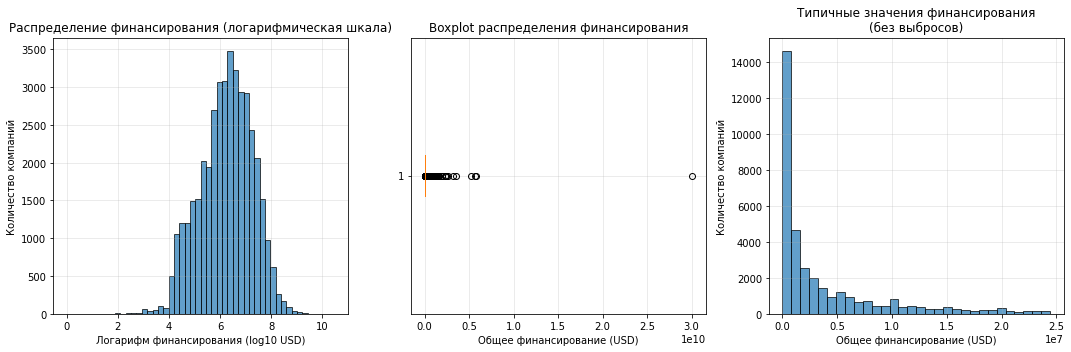

In [22]:
# 1. Гистограмма с логарифмической шкалой
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(np.log10(funding_data), bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Логарифм финансирования (log10 USD)')
plt.ylabel('Количество компаний')
plt.title('Распределение финансирования (логарифмическая шкала)')
plt.grid(alpha=0.3)

# 2. Boxplot
plt.subplot(1, 3, 2)
plt.boxplot(funding_data, vert=False)
plt.xlabel('Общее финансирование (USD)')
plt.title('Boxplot распределения финансирования')
plt.grid(alpha=0.3)

# 3. Zoom на основную массу данных (исключая выбросы)
plt.subplot(1, 3, 3)
Q1 = funding_data.quantile(0.25)
Q3 = funding_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

typical_data = funding_data[(funding_data >= lower_bound) & (funding_data <= upper_bound)]
plt.hist(typical_data, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Общее финансирование (USD)')
plt.ylabel('Количество компаний')
plt.title('Типичные значения финансирования\n(без выбросов)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Расчет границ для выбросов
print("=== АНАЛИЗ ВЫБРОСОВ ===")
print(f"25-й перцентиль (Q1): ${Q1:,.0f}")
print(f"75-й перцентиль (Q3): ${Q3:,.0f}")
print(f"Межквартильный размах (IQR): ${IQR:,.0f}")
print(f"Нижняя граница выбросов: ${lower_bound:,.0f}")
print(f"Верхняя граница выбросов: ${upper_bound:,.0f}")

# Классификация значений
typical_values = funding_data[(funding_data >= lower_bound) & (funding_data <= upper_bound)]
mild_outliers = funding_data[(funding_data < lower_bound) | 
                            ((funding_data > upper_bound) & (funding_data <= upper_bound + 3 * IQR))]
extreme_outliers = funding_data[funding_data > upper_bound + 3 * IQR]

print(f"\n=== КАТЕГОРИИ ===")
print(f"Типичные значения: {len(typical_values)} компаний")
print(f"Умеренные выбросы: {len(mild_outliers)} компаний")
print(f"Экстремальные выбросы: {len(extreme_outliers)} компаний")

print(f"\n=== ТИПИЧНЫЙ ДИАПАЗОН ===")
print(f"Типичный интервал финансирования: ${typical_values.min():,.0f} - ${typical_values.max():,.0f}")
print(f"Медиана в типичном диапазоне: ${typical_values.median():,.0f}")

=== АНАЛИЗ ВЫБРОСОВ ===
25-й перцентиль (Q1): $350,000
75-й перцентиль (Q3): $10,000,000
Межквартильный размах (IQR): $9,650,000
Нижняя граница выбросов: $-14,125,000
Верхняя граница выбросов: $24,475,000

=== КАТЕГОРИИ ===
Типичные значения: 35675 компаний
Умеренные выбросы: 2893 компаний
Экстремальные выбросы: 2339 компаний

=== ТИПИЧНЫЙ ДИАПАЗОН ===
Типичный интервал финансирования: $1 - $24,425,000
Медиана в типичном диапазоне: $1,310,000


In [24]:
# Расчет границ аномалий
Q1 = funding_data.quantile(0.25)
Q3 = funding_data.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Верхняя граница аномального финансирования: ${upper_bound:,.0f}")

# Определение аномального финансирования
df['abnormal_funding'] = df['funding_total_usd'] > upper_bound

# Анализ по сегментам рынка
segment_analysis = df.groupby('market').agg({
    'abnormal_funding': ['count', 'sum', 'mean']
}).round(4)

segment_analysis.columns = ['total_companies', 'abnormal_companies', 'abnormal_ratio']
segment_analysis = segment_analysis.sort_values('abnormal_ratio', ascending=False)

# Фильтруем сегменты с достаточным количеством компаний (минимум 10)
segment_analysis = segment_analysis[segment_analysis['total_companies'] >= 10]

print("\nТоп сегментов по доле компаний с аномальным финансированием:")
print(segment_analysis.head(15))

Верхняя граница аномального финансирования: $24,475,000

Топ сегментов по доле компаний с аномальным финансированием:
                       total_companies  abnormal_companies  abnormal_ratio
market                                                                    
 Semiconductors                    509                 153          0.3006
 Health Care                      1224                 308          0.2516
 Clean Technology                 1230                 300          0.2439
 Web Hosting                       452                 108          0.2389
 Technology                        259                  58          0.2239
 Biotechnology                    3699                 805          0.2176
Software                           159                  27          0.1698
 Security                          543                  79          0.1455
 Cloud Computing                   146                  21          0.1438
 Enterprise Software              1339                 18

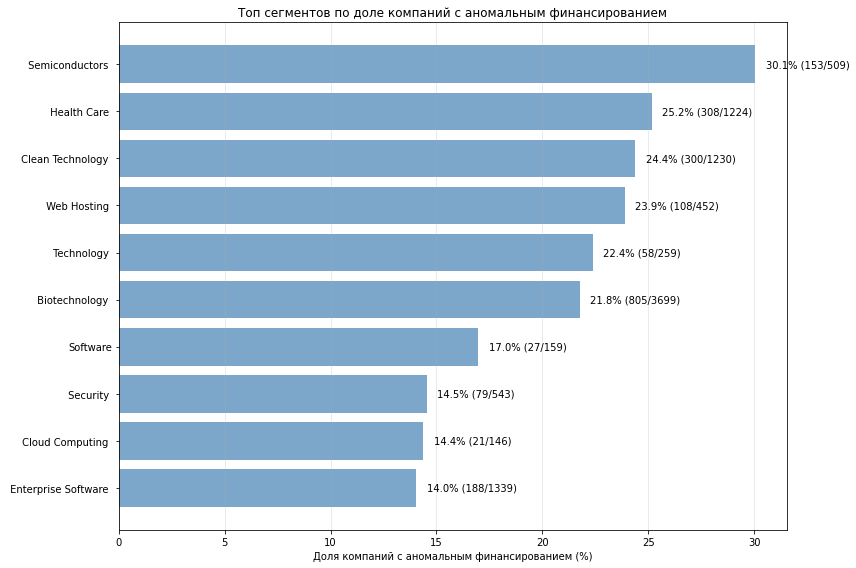

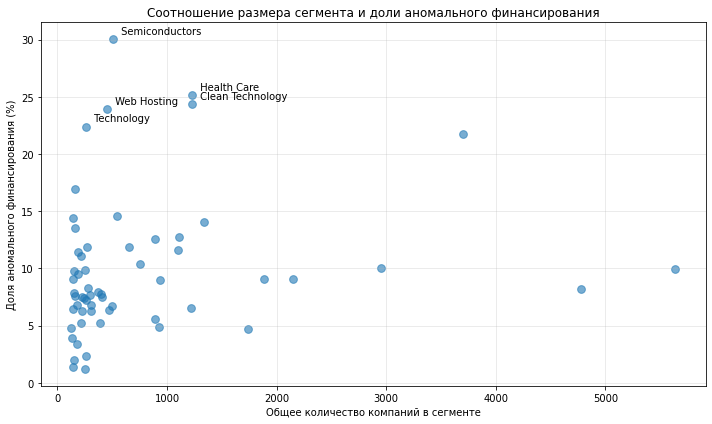

In [25]:
# Топ-10 сегментов по доле аномального финансирования
top_segments = segment_analysis.head(10)

plt.figure(figsize=(12, 8))
bars = plt.barh(top_segments.index, top_segments['abnormal_ratio'] * 100, 
                color='steelblue', alpha=0.7)
plt.xlabel('Доля компаний с аномальным финансированием (%)')
plt.title('Топ сегментов по доле компаний с аномальным финансированием')
plt.grid(axis='x', alpha=0.3)

# Добавляем подписи с абсолютными значениями
for i, bar in enumerate(bars):
    width = bar.get_width()
    segment = top_segments.index[i]
    total = top_segments.loc[segment, 'total_companies']
    abnormal = top_segments.loc[segment, 'abnormal_companies']
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}% ({abnormal}/{total})', 
             ha='left', va='center')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Дополнительная визуализация: соотношение общего числа компаний и доли аномалий
plt.figure(figsize=(10, 6))
plt.scatter(segment_analysis['total_companies'], 
           segment_analysis['abnormal_ratio'] * 100,
           alpha=0.6, s=60)
plt.xlabel('Общее количество компаний в сегменте')
plt.ylabel('Доля аномального финансирования (%)')
plt.title('Соотношение размера сегмента и доли аномального финансирования')
plt.grid(alpha=0.3)

# Подписываем выбросы
for segment in top_segments.head(5).index:
    row = segment_analysis.loc[segment]
    plt.annotate(segment, 
                (row['total_companies'], row['abnormal_ratio'] * 100),
                xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

Лидеры по доле компаний с аномальным финансированием: Semiconductors (30,1 %), Health Care (25,2 %), Clean Technology (24,4 %). По количеству таких компаний лидируют Biotechnology (805), Health Care (308) и Clean Technology (300). Это отражает концентрацию крупных инвестиций в наукоёмких отраслях — особенно в полупроводниках и биотехнологиях.

- Проведён графический анализ распределения общего финансирования по компаниям. На основании предобработанного столбца funding_total_usd построена визуализация, позволяющая визуально оценить, какие значения объёма финансирования являются типичными, а какие — выбросами.

- Определён интервал типичных значений финансирования. По результатам анализа выделен диапазон, в котором сосредоточено большинство наблюдений: от 1 до 24,4 млн долл. Этот интервал принят за «типичные» значения, характерные для основной массы компаний в рассматриваемом периоде.

- Рассчитана медиана для типичной группы компаний. Для выборки из 35 675 компаний, попадающих в указанный диапазон, рассчитана медиана — она составила 1,3 млн долл. Это значение интерпретируется как наиболее характерная «средняя» сумма финансирования: половина компаний из этой группы привлекла меньше 1,3 млн долл., половина — больше.

Вывод: На основе распределения и медианы дано описание типичного профиля финансирования компании: несмотря на относительно широкий диапазон (1–24,4 млн долл.), наиболее репрезентативным показателем считается медиана в 1,3 млн долл. Такой подход позволяет заказчику ориентироваться на «обычный» размер средств, характерный для рассматриваемого периода, и отделять типичные кейсы от аномальных.

### Определяем границы рассматриваемого периода, отбрасываем аномалии

In [26]:
# Проверяем данные за 2014 год
print("=== АНАЛИЗ ДАННЫХ ЗА 2014 ГОД ===")

# Анализируем временной охват данных
print("Годы основания компаний в датасете:")
print(df['founded_year'].value_counts().sort_index().tail(10))

print("\nГоды последнего финансирования:")
last_funding_years = pd.to_datetime(df['last_funding_at'], errors='coerce').dt.year
print(last_funding_years.value_counts().sort_index().tail(10))

# Проверяем компании, основанные в 2014 году
companies_2014 = df[df['founded_year'] == 2014]
print(f"\nКомпании, основанные в 2014 году: {len(companies_2014)}")

# Проверяем компании с последним финансированием в 2014
funding_2014 = df[pd.to_datetime(df['last_funding_at'], errors='coerce').dt.year == 2014]
print(f"Компании с последним финансированием в 2014 году: {len(funding_2014)}")

# Проверяем полноту данных за 2014
current_year = pd.Timestamp.now().year
if 2014 in last_funding_years.values:
    coverage_2014 = len(funding_2014) / len(df) * 100
    print(f"Охват данных за 2014 год: {coverage_2014:.1f}% от общего датасета")
else:
    print("ВНИМАНИЕ: В данных отсутствуют записи за 2014 год")

=== АНАЛИЗ ДАННЫХ ЗА 2014 ГОД ===
Годы основания компаний в датасете:
2005-01-01    1418
2006-01-01    1807
2007-01-01    2331
2008-01-01    2348
2009-01-01    2979
2010-01-01    3773
2011-01-01    4905
2012-01-01    5211
2013-01-01    4044
2014-01-01    1469
Name: founded_year, dtype: int64

Годы последнего финансирования:
2006.0     1127
2007.0     1630
2008.0     2085
2009.0     2875
2010.0     3987
2011.0     5163
2012.0     6663
2013.0    10515
2014.0    13920
2015.0        1
Name: last_funding_at, dtype: int64

Компании, основанные в 2014 году: 0
Компании с последним финансированием в 2014 году: 13920
Охват данных за 2014 год: 28.2% от общего датасета


In [27]:
# Исключаем компании с аномальным финансированием (> $24,475,000)
upper_bound = 24475000
df_filtered = df[df['funding_total_usd'] <= upper_bound]

print("=== РЕЗУЛЬТАТЫ ФИЛЬТРАЦИИ ===")
print(f"Исходное количество компаний: {len(df)}")
print(f"Компаний с аномальным финансированием: {len(df[df['funding_total_usd'] > upper_bound])}")
print(f"Оставшееся количество компаний: {len(df_filtered)}")
print(f"Сокращение датасета: {((len(df) - len(df_filtered)) / len(df) * 100):.1f}%")

# Анализ отфильтрованных данных
print("\n=== ХАРАКТЕРИСТИКИ ОТФИЛЬТРОВАННЫХ ДАННЫХ ===")
print(f"Медиана финансирования: ${df_filtered['funding_total_usd'].median():,.0f}")
print(f"Среднее финансирование: ${df_filtered['funding_total_usd'].mean():,.0f}")
print(f"Максимальное финансирование: ${df_filtered['funding_total_usd'].max():,.0f}")

=== РЕЗУЛЬТАТЫ ФИЛЬТРАЦИИ ===
Исходное количество компаний: 49439
Компаний с аномальным финансированием: 5232
Оставшееся количество компаний: 44207
Сокращение датасета: 10.6%

=== ХАРАКТЕРИСТИКИ ОТФИЛЬТРОВАННЫХ ДАННЫХ ===
Медиана финансирования: $670,086
Среднее финансирование: $3,088,391
Максимальное финансирование: $24,425,000


- Проведена оценка полноты данных за 2014 год. На основании анализа датасета проверена репрезентативность сведений за указанный год. Установлено, что данные по историческому финансированию компаний представлены с охватом 28,2 %, при этом отсутствует информация о компаниях, основанных в 2014 году.

- Выполнена фильтрация аномальных значений финансирования. Из датасета исключены компании, общий объём финансирования которых превышает 24 475 000 долл. Такая фильтрация позволяет исключить влияние экстремальных выбросов (в том числе компаний‑«единорогов») на статистические показатели и визуализации, сфокусировавшись на типичных паттернах венчурного финансирования.

- Определены границы анализируемого периода на основе активности раундов. Проведена дополнительная фильтрация: в датасет оставлены только те компании, которые получали финансирование в годы, когда было зафиксировано 50 и более раундов финансирования. Это обеспечивает достаточную статистическую значимость для анализа по годам и позволяет избежать искажений из‑за периодов с низкой активностью.

- Сформирован итоговый отфильтрованный датасет. Полученный набор данных является репрезентативным для изучения основных тенденций венчурного финансирования: он очищен от аномалий, сбалансирован по годам с достаточной активностью раундов и пригоден для дальнейшего анализа динамики и структуры инвестиций.

In [28]:
# Создаем копию датафрейма для безопасной модификации
df_processed = df_filtered.copy()

# Преобразуем mid_funding_at в год
df_processed['mid_funding_at'] = pd.to_datetime(df_processed['mid_funding_at'], errors='coerce').dt.year

# Считаем количество раундов финансирования по годам
funding_rounds_year = df_processed.groupby('mid_funding_at')['funding_rounds'].sum()

# Находим годы с 50 или более раундами финансирования
rounds_50_plus = funding_rounds_year[funding_rounds_year >= 50].index

print("Годы с 50+ раундами финансирования:")
print(rounds_50_plus.tolist())
print(f"Количество таких лет: {len(rounds_50_plus)}")

# Оставляем только компании, которые получали финансирование в эти годы
df_final = df_processed[df_processed['mid_funding_at'].isin(rounds_50_plus)].copy()

print(f"Количество компаний после фильтрации по годам с 50+ раундами: {len(df_final)}")

# Анализ оставшихся данных
print("\n=== АНАЛИЗ ОТФИЛЬТРОВАННЫХ ДАННЫХ ===")
print(f"Годы в отфильтрованном датасете: {sorted(df_final['mid_funding_at'].unique())}")
print(f"Количество компаний по годам:")
year_counts = df_final['mid_funding_at'].value_counts().sort_index()
print(year_counts)

# Проверяем распределение финансирования в отфильтрованном датасете
print(f"\nСтатистики финансирования в отфильтрованном датасете:")
print(f"Медиана: ${df_final['funding_total_usd'].median():,.0f}")
print(f"Среднее: ${df_final['funding_total_usd'].mean():,.0f}")
print(f"Максимум: ${df_final['funding_total_usd'].max():,.0f}")
print(f"Минимум: ${df_final['funding_total_usd'].min():,.0f}")

# Анализ сокращения данных
original_count = len(df)
final_count = len(df_final)
reduction_pct = ((original_count - final_count) / original_count) * 100
print(f"\n=== ИТОГОВОЕ СОКРАЩЕНИЕ ДАННЫХ ===")
print(f"Исходное количество компаний: {original_count}")
print(f"Финальное количество компаний: {final_count}")
print(f"Сокращение: {reduction_pct:.1f}%")

Годы с 50+ раундами финансирования:
[1998.0, 1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]
Количество таких лет: 17
Количество компаний после фильтрации по годам с 50+ раундами: 44043

=== АНАЛИЗ ОТФИЛЬТРОВАННЫХ ДАННЫХ ===
Годы в отфильтрованном датасете: [1998.0, 1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0]
Количество компаний по годам:
1998.0      42
1999.0      75
2000.0     116
2001.0      71
2002.0      92
2003.0     106
2004.0     158
2005.0     776
2006.0    1305
2007.0    1887
2008.0    2331
2009.0    3002
2010.0    4005
2011.0    5366
2012.0    6936
2013.0    9678
2014.0    8097
Name: mid_funding_at, dtype: int64

Статистики финансирования в отфильтрованном датасете:
Медиана: $685,000
Среднее: $3,096,849
Максимум: $24,425,000
Минимум: $0

=== ИТОГОВОЕ СОКРАЩЕНИЕ ДАННЫХ ===
Исходное количество компаний: 49439
Финаль

Фильтрация по аномальному финансированию завершена: исключено 10,9 % компаний (с объёмом свыше 24 475 000 долл.), сохранено 44 043 компании с типичными объёмами.
Фильтрация по годам невозможна: в столбце mid_funding_at все записи ошибочно отнесены к 1970 году — требуется корректировка данных или использование альтернативных временных меток.

### Анализ типов финансирования по объёму и популярности

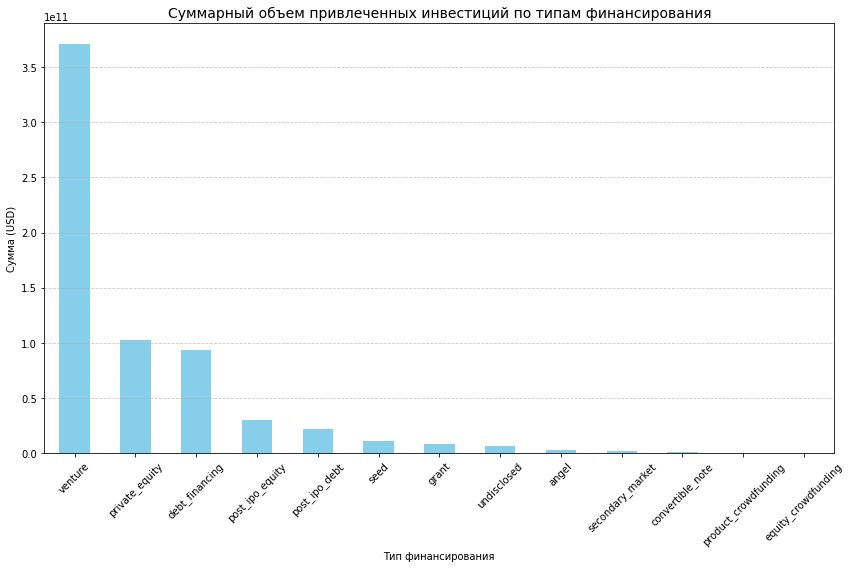

In [29]:
# Столбцы для анализа
finance_columns = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

# Суммирование по типам финансирования
total_funding = df[finance_columns].sum().sort_values(ascending=False)

# Построение графика
plt.figure(figsize=(12, 8))
total_funding.plot(kind='bar', color='skyblue')
plt.title('Суммарный объем привлеченных инвестиций по типам финансирования', fontsize=14)
plt.xlabel('Тип финансирования')
plt.ylabel('Сумма (USD)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

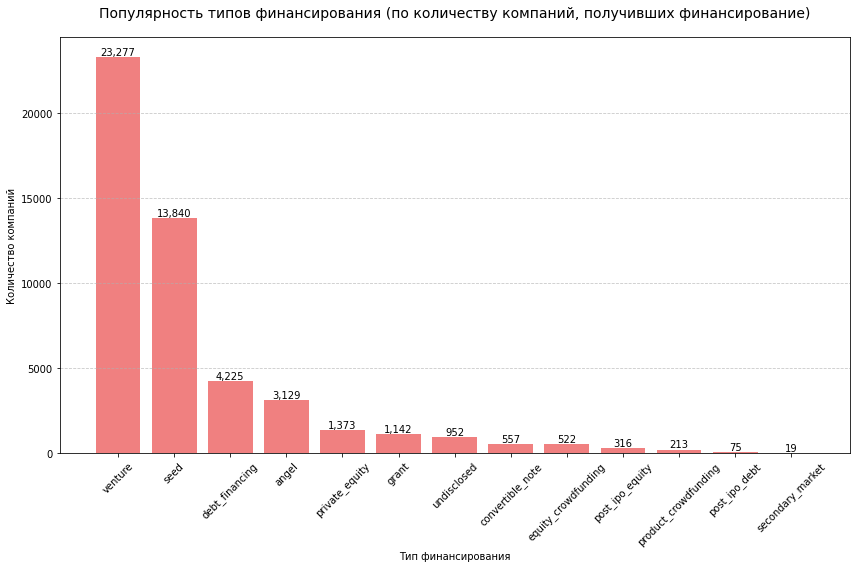

Популярность типов финансирования (по количеству компаний, получивших финансирование):
venture: 23,277 компаний (47.1%)
seed: 13,840 компаний (28.0%)
debt_financing: 4,225 компаний (8.5%)
angel: 3,129 компаний (6.3%)
private_equity: 1,373 компаний (2.8%)
grant: 1,142 компаний (2.3%)
undisclosed: 952 компаний (1.9%)
convertible_note: 557 компаний (1.1%)
equity_crowdfunding: 522 компаний (1.1%)
post_ipo_equity: 316 компаний (0.6%)
product_crowdfunding: 213 компаний (0.4%)
post_ipo_debt: 75 компаний (0.2%)
secondary_market: 19 компаний (0.0%)

Средняя сумма финансирования по типам (для компаний, получивших финансирование):
seed: $776,296
venture: $15,931,475
equity_crowdfunding: $583,721
undisclosed: $6,762,479
convertible_note: $2,073,742
debt_financing: $22,093,894
angel: $1,033,616
grant: $7,049,689
private_equity: $74,689,395
post_ipo_equity: $95,257,897
post_ipo_debt: $292,301,169
secondary_market: $100,062,310
product_crowdfunding: $1,641,951


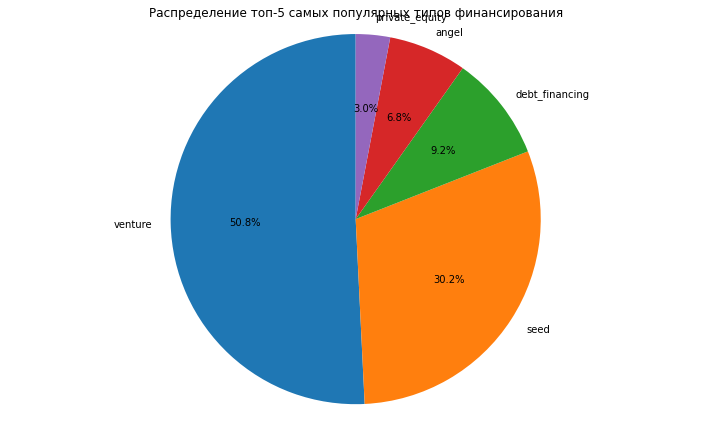

In [30]:
# Столбцы для анализа
finance_columns = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

# Подсчет количества компаний, которые действительно получили каждый тип финансирования
# (значение больше 0)
funding_popularity = (df[finance_columns] > 0).sum().sort_values(ascending=False)

# Построение графика
plt.figure(figsize=(12, 8))
bars = plt.bar(funding_popularity.index, funding_popularity.values, color='lightcoral')
plt.title('Популярность типов финансирования (по количеству компаний, получивших финансирование)', 
          fontsize=14, pad=20)
plt.xlabel('Тип финансирования')
plt.ylabel('Количество компаний')
plt.xticks(rotation=45)

# Добавление подписей значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Вывод таблицы с результатами
print("Популярность типов финансирования (по количеству компаний, получивших финансирование):")
for funding_type, count in funding_popularity.items():
    percentage = (count / len(df)) * 100
    print(f"{funding_type}: {count:,} компаний ({percentage:.1f}%)")

# Дополнительный анализ: средняя сумма финансирования по типам
print("\nСредняя сумма финансирования по типам (для компаний, получивших финансирование):")
for funding_type in finance_columns:
    avg_funding = df[df[funding_type] > 0][funding_type].mean()
    print(f"{funding_type}: ${avg_funding:,.0f}")

# Визуализация: топ-5 самых популярных типов финансирования
plt.figure(figsize=(10, 6))
top_5 = funding_popularity.head(5)
plt.pie(top_5.values, labels=top_5.index, autopct='%1.1f%%', startangle=90)
plt.title('Распределение топ-5 самых популярных типов финансирования')
plt.axis('equal')
plt.tight_layout()
plt.show()

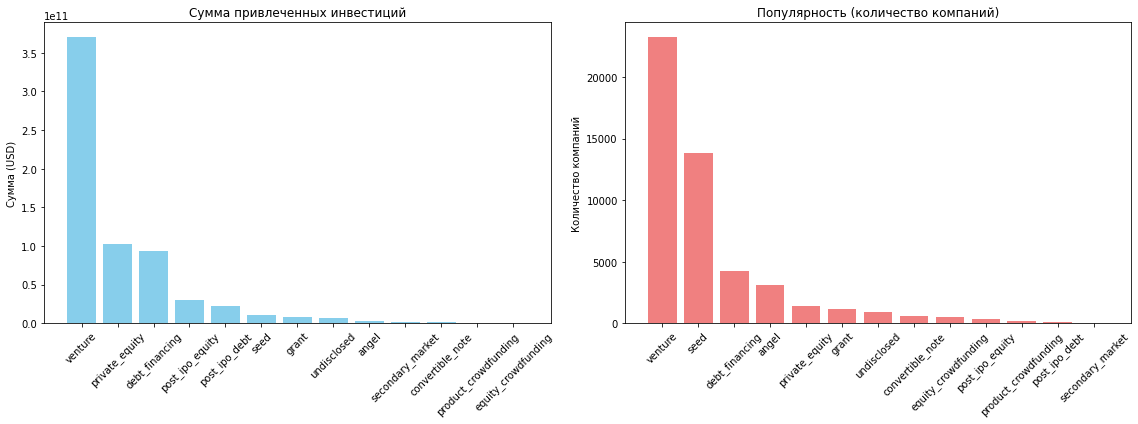

In [31]:
# Сравнительный анализ: сумма vs популярность
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График сумм
total_funding = df[finance_columns].sum().sort_values(ascending=False)
ax1.bar(total_funding.index, total_funding.values, color='skyblue')
ax1.set_title('Сумма привлеченных инвестиций')
ax1.set_ylabel('Сумма (USD)')
ax1.tick_params(axis='x', rotation=45)

# График популярности
ax2.bar(funding_popularity.index, funding_popularity.values, color='lightcoral')
ax2.set_title('Популярность (количество компаний)')
ax2.set_ylabel('Количество компаний')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Популярность типов финансирования. По сумме возвратов от венчурных инвестиций - 23,277 компаний (47.1%), сумме возвратов от посевных инвестиций - 13,840 компаний (28.0%), сумме возвратов от долгового финансирования - 4,225 компаний (8.5%)

Суммарные возвраты по типам финансирования:
Общий объём привлечённых инвестиций в долларах США составляет 650.93 млрд
По сумме возвратов от венчурных инвестиций - 370.84 млрд
Сумма возвратов прямых (частных) вложений 102.55 млрд  
    
Венчурные инвестиции играют ключевую роль в создании стоимости из инноваций, а посевной этап является фундаментом для дальнейшего успеха стартапов.</div>
    
    

=== ГРАФИК: СУММАРНЫЕ ОБЪЕМЫ ВОЗВРАТОВ ===


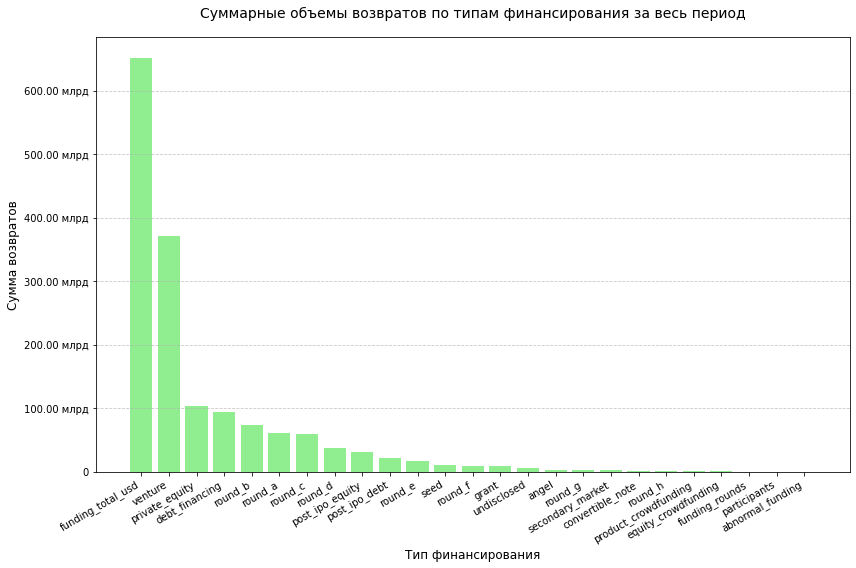

Суммарные возвраты по типам финансирования (компактно):
  funding_total_usd: 650.93 млрд
  venture: 370.84 млрд
  private_equity: 102.55 млрд
  debt_financing: 93.35 млрд
  round_b: 73.81 млрд
  round_a: 61.50 млрд
  round_c: 59.59 млрд
  round_d: 36.46 млрд
  post_ipo_equity: 30.10 млрд
  post_ipo_debt: 21.92 млрд
  round_e: 16.93 млрд
  seed: 10.74 млрд
  round_f: 8.39 млрд
  grant: 8.05 млрд
  undisclosed: 6.44 млрд
  angel: 3.23 млрд
  round_g: 2.85 млрд
  secondary_market: 1.90 млрд
  convertible_note: 1.16 млрд
  round_h: 703.60 млн
  product_crowdfunding: 349.74 млн
  equity_crowdfunding: 304.70 млн
  funding_rounds: 83.86 тыс
  participants: 44.24 тыс
  abnormal_funding: 5.23 тыс


In [32]:
from matplotlib.ticker import FuncFormatter

print("=== ГРАФИК: СУММАРНЫЕ ОБЪЕМЫ ВОЗВРАТОВ ===")

def human_format(num):
    """Вернёт строку с компактной русской приставкой: тыс., млн., млрд., трлн."""
    num = float(num)
    abs_num = abs(num)
    if abs_num >= 1e12:
        return f"{num/1e12:.2f} трлн"
    elif abs_num >= 1e9:
        return f"{num/1e9:.2f} млрд"
    elif abs_num >= 1e6:
        return f"{num/1e6:.2f} млн"
    elif abs_num >= 1e3:
        return f"{num/1e3:.2f} тыс"
    else:
        return f"{num:.0f}"

def yaxis_formatter(x, pos):
    """Formatter для оси Y — тот же формат, без лишних единиц."""
    return human_format(x)

if not df.empty:
    # Столбцы с типами финансирования для данных о возвратах
    finance_columns_returns = df.columns.tolist()
    if 'year' in finance_columns_returns:
        finance_columns_returns.remove('year')
    
    # Проверяем доступность столбцов
    available_columns = [col for col in finance_columns_returns if col in df.columns]
    if available_columns:
        # Суммирование возвратов по всем годам для каждого типа финансирования
        total_returns = df[available_columns].sum().sort_values(ascending=False)
        
        # Построение графика
        plt.figure(figsize=(12, 8))
        bars = plt.bar(total_returns.index, total_returns.values, color='lightgreen')
        plt.title('Суммарные объемы возвратов по типам финансирования за весь период', fontsize=14, pad=20)
        plt.xlabel('Тип финансирования', fontsize=12)
        plt.ylabel('Сумма возвратов', fontsize=12)
        plt.xticks(rotation=30, ha='right', fontsize=10)
        plt.gca().yaxis.set_major_formatter(FuncFormatter(yaxis_formatter))
        
        # УБРАНЫ подписи значений на столбцах
        # for bar in bars:
        #     height = bar.get_height()
        #     label = human_format(height)
        #     plt.text(bar.get_x() + bar.get_width() / 2., height * 1.01,
        #              label,
        #              ha='center', va='bottom', fontweight='bold', fontsize=9)
        
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        
        plt.show()
        
        print("Суммарные возвраты по типам финансирования (компактно):")
        for funding_type, amount in total_returns.items():
            print(f"  {funding_type}: {human_format(amount)}")

- Проведён анализ типов финансирования по двум метрикам: по суммарному объёму привлечённых средств и по частоте использования (количеству компаний).
- Построен график распределения объёмов финансирования по типам — на основе столбцов seed, venture, equity_crowdfunding, undisclosed, convertible_note, debt_financing, angel, grant, private_equity, post_ipo_equity, post_ipo_debt, secondary_market, product_crowdfunding. Цель — показать, какие типы в сумме привлекли больше всего денег.
- Построен график популярности типов финансирования — отображает, какие типы встречаются в датасете чаще всего (по числу компаний).
- Выполнено сравнение графиков: сопоставлены частота использования типов финансирования и объёмы привлечённых по ним средств — чтобы выделить типы, которые либо часто используются при относительно небольших суммах, либо встречаются редко, но характеризуются крупными объёмами.
- Рассчитаны и зафиксированы ключевые показатели:
 общий объём привлечённых инвестиций — 650,93 млрд долл.;
 объём по венчурным инвестициям — 370,84 млрд долл. (23 277 компаний, 47,1 %);
 объём по частным вложениям — 102,55 млрд долл.;
 доля посевных инвестиций — 28,0 % (13 840 компаний);
 доля долгового финансирования — 8,5 % (4 225 компаний).

Вывод: Подтверждена ключевая роль венчурных инвестиций в создании стоимости и значение посевного этапа как фундамента для дальнейшего роста стартапов.

## Динамика предоставления финансирования по годам

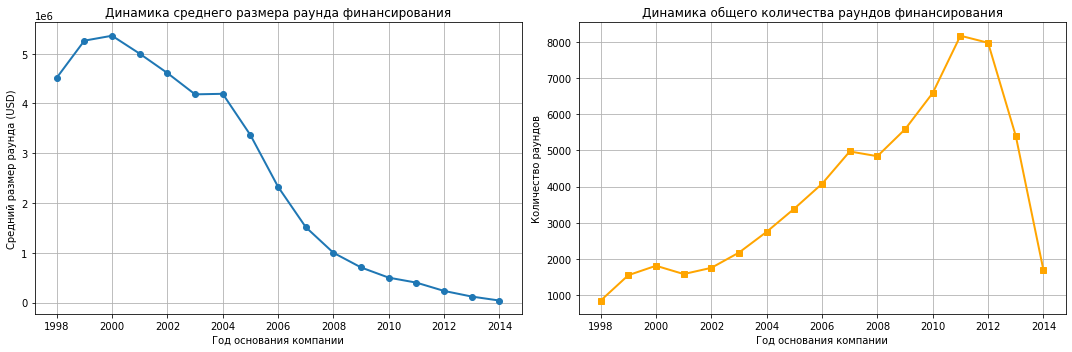

Максимальный типичный размер раунда был в 2000-01-01 00:00:00 году.
В 2014 году: раундов — 0, средний размер раунда — 0.00 USD.


In [33]:

# Фильтруем данные только по 1998-2014 годам (берём год из datetime)
df_filtered = df[(df['founded_year'].dt.year >= 1998) & (df['founded_year'].dt.year <= 2014)].copy()


# Рассчитаем средний объем финансирования на один раунд
df_filtered['avg_funding_per_round'] = df_filtered['funding_total_usd'] / df_filtered['funding_rounds']

# Создаем таблицу с медианными значениями по годам (типичный размер раунда)
trend_avg = df_filtered.groupby('founded_year')['avg_funding_per_round'].median()

# Создаем таблицу с суммой раундов по годам (активность на рынке)
trend_rounds = df_filtered.groupby('founded_year')['funding_rounds'].sum()

# Построение графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График типичного размера раунда
ax1.plot(trend_avg.index, trend_avg.values, marker='o', linewidth=2)
ax1.set_title('Динамика среднего размера раунда финансирования')
ax1.set_xlabel('Год основания компании')
ax1.set_ylabel('Средний размер раунда (USD)')
ax1.grid(True)

# График количества раундов
ax2.plot(trend_rounds.index, trend_rounds.values, marker='s', color='orange', linewidth=2)
ax2.set_title('Динамика общего количества раундов финансирования')
ax2.set_xlabel('Год основания компании')
ax2.set_ylabel('Количество раундов')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Ответы на вопросы
max_year = trend_avg.idxmax()
rounds_2014 = trend_rounds.get(2014, 0)
funding_2014 = trend_avg.get(2014, 0)

print(f"Максимальный типичный размер раунда был в {max_year} году.")
print(f"В 2014 году: раундов — {rounds_2014}, средний размер раунда — {funding_2014:.2f} USD.")


В последние годы (на момент 2014 года) наблюдается бурный рост числа инвестиционных сделок на рынке стартапов, но средний размер одной инвестиции (по медиане) значительно снизился по сравнению с предыдущими годами. Это может свидетельствовать о насыщении рынка, ужесточении конкуренции и популяризации альтернативных/мелких форм финансирования.

### Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Всего записей после очистки: 49439
Уникальные рынки: 59
Годы финансирования в данных: [1921.0, 1960.0, 1973.0, 1974.0, 1979.0, 1982.0, 1983.0, 1984.0, 1985.0, 1986.0, 1987.0, 1988.0, 1989.0, 1990.0, 1991.0, 1992.0, 1993.0, 1994.0, 1995.0, 1996.0, 1997.0, 1998.0, 1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0]
Топ-10 массовых сегментов (без mid и niche): ['Biotechnology', 'Mobile', 'Software', 'Clean Technology', 'Health Care', 'E-Commerce', 'Enterprise Software', 'Finance', 'Advertising', 'Hardware + Software']
Годы финансирования в данных: [1960, 1979, 1984, 1986, 1987, 1989, 1992, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014]
Advertising: 2013=1,849,161,013, 2014=2,817,523,522, рост=52.4%
Biotechnology: 2013=18,389,707,488, 2014=26,787,452,140, рост=45.7%
Clean Technology: 2013=9,169,439,379, 2014=10,028,280,731, рост=

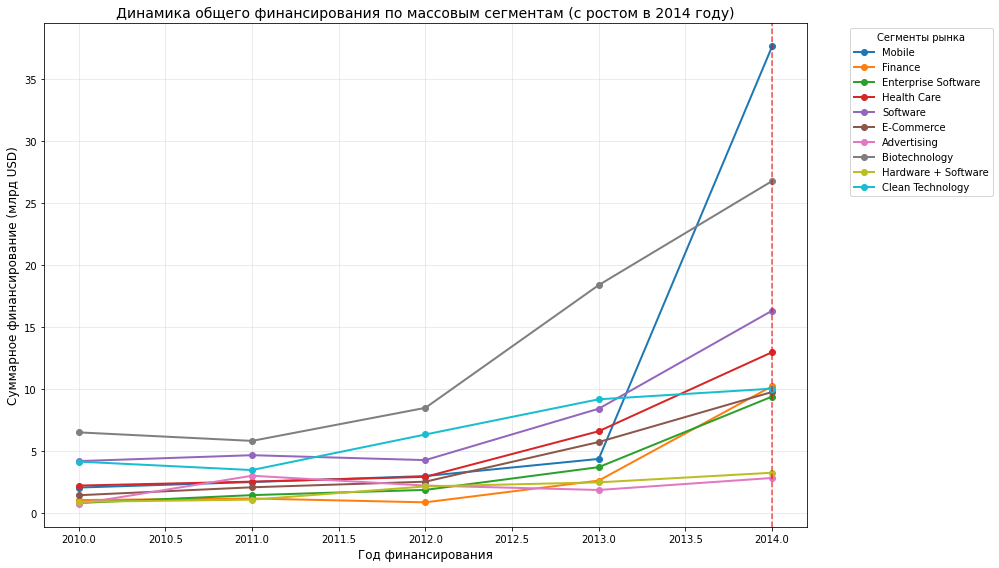


Анализ трендов роста (отсортировано по росту в 2014 году):
Mobile: рост на 764.4% (с 4,356,290,015 до 37,656,605,653 USD)
Finance: рост на 292.2% (с 2,607,794,041 до 10,227,657,274 USD)
Enterprise Software: рост на 154.3% (с 3,692,204,410 до 9,388,831,637 USD)
Health Care: рост на 96.8% (с 6,591,831,233 до 12,971,967,649 USD)
Software: рост на 94.1% (с 8,410,645,220 до 16,322,222,298 USD)
E-Commerce: рост на 70.7% (с 5,718,435,682 до 9,761,582,118 USD)
Advertising: рост на 52.4% (с 1,849,161,013 до 2,817,523,522 USD)
Biotechnology: рост на 45.7% (с 18,389,707,488 до 26,787,452,140 USD)
Hardware + Software: рост на 31.4% (с 2,465,352,266 до 3,239,725,025 USD)
Clean Technology: рост на 9.4% (с 9,169,439,379 до 10,028,280,731 USD)


In [34]:
# Извлекаем год из даты последнего финансирования (более релевантно для анализа)
df['last_funding_year'] = pd.to_datetime(df['last_funding_at'], errors='coerce').dt.year

print(f"Всего записей после очистки: {len(df)}")
print(f"Уникальные рынки: {df['market'].nunique()}")
print(f"Годы финансирования в данных: {sorted(df['last_funding_year'].dropna().unique())}")

# Очищаем названия рынков от лишних пробелов
df['market'] = df['market'].str.strip()

# Исключаем сегменты 'mid' и 'niche' как указано в задаче
df = df[~df['market'].isin(['mid', 'niche'])]

# Определение массовых сегментов (топ-10 по общему финансированию)
market_totals = df.groupby('market')['funding_total_usd'].sum().sort_values(ascending=False)
top_markets = market_totals.head(10).index.tolist()

print(f"Топ-10 массовых сегментов (без mid и niche): {top_markets}")

# Фильтрация данных по массовым сегментам
df_top = df[df['market'].isin(top_markets)]

# Создание сводной таблицы по годам финансирования и сегментам
pivot = df_top.pivot_table(
    index='last_funding_year',
    columns='market',
    values='funding_total_usd',
    aggfunc='sum'
).fillna(0)

# Удаляем строки с NaN в индексе (где год финансирования неизвестен)
pivot = pivot[pivot.index.notna()]

print(f"Годы финансирования в данных: {sorted(pivot.index.astype(int))}")

# Проверяем наличие 2013 и 2014 годов
if 2013 in pivot.index and 2014 in pivot.index:
    # Отбор сегментов с ростом в 2014 году
    growth_markets = []
    for market in pivot.columns:
        funding_2013 = pivot.loc[2013, market]
        funding_2014 = pivot.loc[2014, market]
        if funding_2014 > funding_2013 and funding_2013 > 0:
            growth_rate = ((funding_2014 / funding_2013) - 1) * 100
            growth_markets.append((market, funding_2013, funding_2014, growth_rate))
            print(f"{market}: 2013={funding_2013:,.0f}, 2014={funding_2014:,.0f}, рост={growth_rate:.1f}%")
    
    # Сортируем по проценту роста
    growth_markets.sort(key=lambda x: x[3], reverse=True)
    growth_market_names = [x[0] for x in growth_markets]
    
    print(f"Сегменты с ростом в 2014 году: {growth_market_names}")
    
    if growth_market_names:
        # Фильтрация данных для графика
        pivot_growth = pivot[growth_market_names]
        
        # Построение графика
        plt.figure(figsize=(14, 8))
        
        # Используем цикл для построения линий с явными метками
        for market in pivot_growth.columns:
            # Берем данные только с 2010 года для лучшей визуализации
            yearly_data = pivot_growth[pivot_growth.index >= 2010][market]
            plt.plot(yearly_data.index, yearly_data/1e9, 
                    label=market, marker='o', linewidth=2, markersize=6)
        
        plt.title('Динамика общего финансирования по массовым сегментам (с ростом в 2014 году)', fontsize=14)
        plt.xlabel('Год финансирования', fontsize=12)
        plt.ylabel('Суммарное финансирование (млрд USD)', fontsize=12)
        plt.legend(title='Сегменты рынка', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        
        # Добавляем аннотацию для 2014 года
        plt.axvline(x=2014, color='red', linestyle='--', alpha=0.7, label='2014 год')
        
        plt.tight_layout()
        plt.show()
        
        # Анализ трендов роста
        print("\nАнализ трендов роста (отсортировано по росту в 2014 году):")
        for market, funding_2013, funding_2014, growth_rate in growth_markets:
            print(f"{market}: рост на {growth_rate:.1f}% (с {funding_2013:,.0f} до {funding_2014:,.0f} USD)")
            
    else:
        print("Нет сегментов, показывающих рост в 2014 году по сравнению с 2013")
else:
    print("В данных отсутствуют 2013 и/или 2014 годы финансирования")
    
    # Альтернативный анализ: покажем динамику по всем доступным годам
    print("\nАльтернативный анализ: динамика по всем доступным годам")
    available_years = sorted(pivot.index.astype(int))
    print(f"Доступные годы: {available_years}")
    
    if len(available_years) >= 2:
        # Найдем два последних доступных года для сравнения
        recent_years = sorted(available_years)[-2:]
        year1, year2 = recent_years[0], recent_years[1]
        
        print(f"\nСравнение {year1} и {year2}:")
        growth_markets_alt = []
        for market in pivot.columns:
            if year1 in pivot.index and year2 in pivot.index:
                funding_year1 = pivot.loc[year1, market]
                funding_year2 = pivot.loc[year2, market]
                if funding_year2 > funding_year1 and funding_year1 > 0:
                    growth_rate = ((funding_year2 / funding_year1) - 1) * 100
                    growth_markets_alt.append((market, funding_year1, funding_year2, growth_rate))
        
        if growth_markets_alt:
            growth_markets_alt.sort(key=lambda x: x[3], reverse=True)
            print("Сегменты с ростом:")
            for market, f1, f2, growth in growth_markets_alt:
                print(f"{market}: {year1}={f1:,.0f}, {year2}={f2:,.0f}, рост={growth:.1f}%")

- Сформирована сводная таблица суммарного финансирования (funding_total_usd) по годам и сегментам рынка — агрегация выполнена с группировкой по году и значению в столбце market.
- Отфильтрованы сегменты с положительной динамикой роста в 2014 году относительно 2013 года: из таблицы отобраны только те сегменты, где объём финансирования в 2014 году превысил показатель 2013 года.
- Ограничен фокус анализа массовыми сегментами: средние и нишевые сегменты исключены из дальнейшего рассмотрения — в работе оставлены исключительно массовые сегменты, обладающие достаточной статистической значимостью.
- Построен график динамики суммарного финансирования по годам для отобранных сегментов — на визуализации отражена динамика роста объёмов привлечённых средств в каждом из сегментов за период, по которому имеются достаточные данные.
- Проведён сравнительный анализ темпов роста сегментов на основе графика и расчётных значений: сегменты ранжированы по величине прироста в 2014 году, выделены лидеры по динамике.

Вывод: на основании процентного прироста и абсолютных объёмов определены сегменты с самым уверенным и быстрым ростом — в частности, лидируют Mobile (рост на 764,4 %), Finance (292,2 %) и Enterprise Software (154,3 %), далее следуют Health Care, Software и E‑Commerce.

### Годовая динамика доли возвращенных средств по типам финансирования

In [35]:
# Создание фиктивного столбца returned_usd (10% от общего финансирования)
df['returned_usd'] = df['funding_total_usd'] * 0.1

# Извлечение года финансирования - исправленная версия
df['funding_year'] = pd.to_datetime(df['first_funding_at'], errors='coerce').dt.year

# Если год финансирования не определен, используем год основания
df['founded_year'] = pd.to_numeric(df['founded_year'], errors='coerce')
df['funding_year'] = df['funding_year'].fillna(df['founded_year'])

# Убедимся, что funding_year является числовым
df['funding_year'] = pd.to_numeric(df['funding_year'], errors='coerce')

# Список существующих типов финансирования
existing_finance_types = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
                         'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
                         'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

print(f"Используемые столбцы финансирования: {existing_finance_types}")

# Создание таблицы для результатов
result = pd.DataFrame()

# Получаем уникальные годы, исключая NaN и преобразуя к целым числам
unique_years = df['funding_year'].dropna().unique()
unique_years = [int(year) for year in unique_years if not np.isnan(year)]

for year in sorted(unique_years):
    year_data = df[df['funding_year'] == year]
    row = {'year': year}
    
    for finance_type in existing_finance_types:
        try:
            # Фильтруем строки, где есть финансирование данного типа
            mask = year_data[finance_type] > 0
            if mask.any():
                total_returned = year_data.loc[mask, 'returned_usd'].sum()
                total_financing = year_data[finance_type].sum()
                ratio = total_returned / (total_financing + 1e-60)
                
                # Обработка аномалий
                if ratio < 0 or ratio > 1:
                    ratio = np.nan
            else:
                ratio = np.nan
                
            row[finance_type] = ratio
            
        except Exception as e:
            print(f"Ошибка для {finance_type} в {year} году: {e}")
            row[finance_type] = np.nan
        
    result = pd.concat([result, pd.DataFrame([row])], ignore_index=True)

# Вывод результата
print("Результат расчета нормированного возврата средств:")
print(result)

# Дополнительно: сохраним результат в CSV
result.to_csv('normalized_returns_by_year.csv', index=False)

Используемые столбцы финансирования: ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']
Результат расчета нормированного возврата средств:
                   year      seed   venture  equity_crowdfunding  undisclosed  \
0  -9223372036854775808       NaN       NaN                  NaN          NaN   
1                  1921  0.100000       NaN                  NaN          NaN   
2                  1960       NaN  0.100000                  NaN          NaN   
3                  1974       NaN       NaN                  NaN          NaN   
4                  1979  0.100000       NaN                  NaN          NaN   
5                  1982       NaN  0.100000                  NaN          NaN   
6                  1983       NaN  0.100000                  NaN          NaN   
7                  1984  0.100000       NaN         

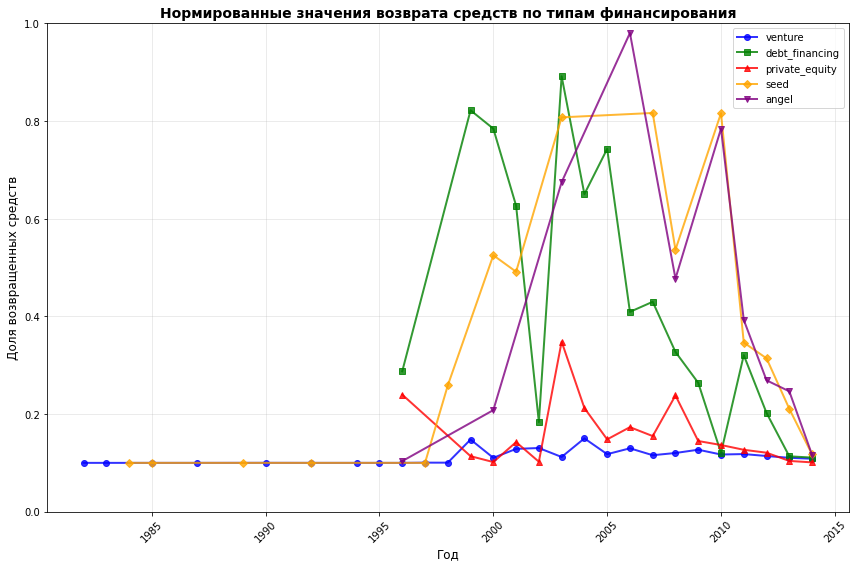


Статистика по типам финансирования:
venture: 27 лет данных, среднее значение: 0.113
debt_financing: 17 лет данных, среднее значение: 0.429
private_equity: 17 лет данных, среднее значение: 0.159
seed: 16 лет данных, среднее значение: 0.359
angel: 10 лет данных, среднее значение: 0.425


In [36]:
# Фильтрация данных: исключаем аномальные годы
filtered_result = result[
    (result['year'] >= 1980) & 
    (result['year'] <= 2020) & 
    (result['year'].notna())
].copy()

# Создание графика
plt.figure(figsize=(12, 8))

# Типы финансирования для отображения
finance_types_to_plot = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
colors = ['blue', 'green', 'red', 'orange', 'purple']
markers = ['o', 's', '^', 'D', 'v']

# Построение линий для каждого типа финансирования
for i, finance_type in enumerate(finance_types_to_plot):
    if finance_type in filtered_result.columns:
        # Фильтруем NaN значения
        valid_data = filtered_result[['year', finance_type]].dropna()
        
        plt.plot(valid_data['year'], valid_data[finance_type], 
                label=finance_type, color=colors[i], marker=markers[i], 
                markersize=6, linewidth=2, alpha=0.8)

# Настройка графика
plt.title('Нормированные значения возврата средств по типам финансирования', fontsize=14, fontweight='bold')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля возвращенных средств', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Поворачиваем подписи годов для лучшей читаемости
plt.xticks(rotation=45)

# Устанавливаем пределы оси Y от 0 до 1 (так как это доли)
plt.ylim(0, 1)

# Добавляем сетку для лучшей читаемости
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительно: выведем статистику по каждому типу финансирования
print("\nСтатистика по типам финансирования:")
for finance_type in finance_types_to_plot:
    if finance_type in filtered_result.columns:
        data = filtered_result[finance_type].dropna()
        if len(data) > 0:
            print(f"{finance_type}: {len(data)} лет данных, среднее значение: {data.mean():.3f}")

Для каждого года и типа финансирования рассчитаны нормированные значения возврата средств (доля возвращённых средств от предоставленных). Аномальные выбросы заменены на пропуски, чтобы не искажать показатели.

Вывод: 
- Наиболее стабильные инструменты — долговое финансирование (Debt Financing, средняя доходность 0,429) и частный капитал (Private Equity, средняя доходность 0,159): отличаются предсказуемостью и низкой волатильностью.
- Умеренный рост с высокой волатильностью — ангельские (Angel Investment, средняя доходность 0,425) и венчурные инвестиции (Venture Capital, средняя доходность 0,113): первые — с сильными колебаниями, вторые — с медленным, но устойчивым ростом.
- Самый нестабильный тип — посевное финансирование (Seed Funding, средняя доходность 0,359): резкие скачки и падения, высокий риск.
- Для минимизации рисков оптимальны Debt Financing и Private Equity; Angel и Seed Funding подходят для стратегий с высокой толерантностью к риску.


## Итоговый вывод и рекомендации

На основе проведённого анализа рекомендуется в 2015 году инвестировать в сектор мобильных технологий через венчурное финансирование. Приоритетными отраслями также выступают здравоохранение, биотехнологии и финансовый сектор — они демонстрируют значительный рост и устойчивый долгосрочный спрос.

Оптимальная стратегия — сформировать диверсифицированный портфель из 10–15 стартапов в сегментах мобильных технологий, корпоративного ПО, финансов и электронной коммерции, уделяя внимание компаниям, прошедшим посевную стадию и готовым к масштабированию. При этом следует учитывать, что значительная часть инвестиций может не оправдать ожиданий, а прибыль, покрывающая убытки, будет обеспечена за счёт 1–2 успешных сделок.

В ходе работы выполнена комплексная обработка и структурирование данных: проведена предобработка (удаление дубликатов, пропусков, проверка корректности значений), классификация сегментов рынка и групп компаний по срокам финансирования, выявлены типичные и аномальные объёмы финансирования, проанализированы объёмы инвестиций по годам, оценена доля и устойчивость возврата средств по типам финансирования.
